<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/OB/0313_%EC%84%B8%EC%85%98_%EB%B9%84%EC%A7%80%EB%8F%84%ED%95%99%EC%8A%B5_%EC%97%B0%EC%8A%B5%EB%AC%B8%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **| 비지도 학습 연습 문제**
___
- 출처 : 핸즈온 머신러닝 Ch09 앙상블 학습과 랜덤 포레스트 연습문제 3, 5, 8, 10번
- 이론적 지식을 묻는 문제의 경우 텍스트 셀을 추가하여 정답을 적어주세요.

In [ ]:
# import libraries
import numpy as np

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt

### **1. k-평균을 사용할 때 적절한 클러스터 개수를 선택할 수 있는 두 가지 기법을 설명하세요.**
___



1️⃣ 엘보우 방법 (Elbow Method)

클러스터 개수
k를 바꿔가면서 **클러스터 내부 제곱합(SSE, inertia)**을 계산하고 그래프로 확인하는 방법
k가 커질수록 클러스터 내부 거리(SSE) 는 계속 감소
그래프가 팔꿈치(elbow) 모양으로 꺾이는 지점의
k를 선택

2️⃣ 실루엣 점수 (Silhouette Score)

각 데이터가 자기 클러스터에 얼마나 잘 속해 있는지를 측정하는 방법

| 값      | 의미           |
| ------ | ------------ |
| 1에 가까움 | 클러스터가 잘 분리됨  |
| 0 근처   | 클러스터 경계에 위치  |
| 음수     | 잘못된 클러스터에 속함 |


### **2. 대규모 데이터셋으로 확장할 수 있는 군집 알고리즘 두 개를 말해보세요. 밀도가 높은 지역을 찾는 군집 알고리즘 두 개는 무엇인가요?**
___


① Mini-Batch K-Means

일반 K-Means의 확장 버전

전체 데이터를 사용하지 않고 작은 mini-batch 데이터로 반복 학습

메모리 사용이 적고 매우 큰 데이터셋에도 적용 가능

② BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)

데이터를 Clustering Feature Tree(CF Tree) 구조로 압축

큰 데이터셋을 요약하면서 단계적으로 클러스터링

대규모 데이터에 효율적

### **3. 가우시안 혼합이 무엇인가요? 어떤 작업에 사용할 수 있나요?**
___


| 항목      | 설명                                   |
| ------- | ------------------------------------ |
| 정의      | 여러 가우시안 분포의 혼합으로 데이터 분포를 모델링하는 확률 모델 |
| 주요 알고리즘 | EM 알고리즘                              |
| 활용      | 군집 분석, 밀도 추정, 이상치 탐지, 데이터 생성         |


### **4. 다음 단계를 따라 올리베티 얼굴 데이터셋을 군집해보자..**
___
전통적인 올리베티 얼굴 데이터셋은 64 X 64 픽셀 크기의 흑백 얼굴 이미지 400개를 가지고 있습니다. 사람 40명의 사진을 10장씩 찍은 것인데, 각 이미지는 4096 크기의 1D 벡터로 펼쳐져 있습니다.

#### **STEP 1. 아래 코드를 실행하여 데이터셋을 불러오세요.**

In [1]:
from sklearn.datasets import fetch_olivetti_faces

olivetti = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


####  **STEP 2. 데이터셋을 훈련 세트, 검증 세트, 테스트 세트로 나누세요.**
해당 데이터셋은 매우 작으므로, `StratifiedShuffleSplit` 함수를 이용하여, 계층적 샘플링으로 각 세트에 동일한 사람의 얼굴이 고루 섞이도록 하세요.

In [4]:
from sklearn.model_selection import StratifiedShuffleSplit
X=olivetti['data']
y=olivetti['target']
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_val_idx, test_idx in split.split(X, y):
    X_train_val = X[train_val_idx]
    y_train_val = y[train_val_idx]
    X_test = X[test_idx]
    y_test = y[test_idx]

    # Step 2 계속: X_train_val을 다시 훈련 세트와 검증 세트로 분할
split_val = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, val_idx in split_val.split(X_train_val, y_train_val):
    X_train = X_train_val[train_idx]
    y_train = y_train_val[train_idx]
    X_valid = X_train_val[val_idx]
    y_valid = y_train_val[val_idx]

# 결과 확인
print(f"전체 데이터: {len(X)}")
print(f"훈련 세트: {len(X_train)}")
print(f"검증 세트: {len(X_valid)}")
print(f"테스트 세트: {len(X_test)}")

전체 데이터: 400
훈련 세트: 256
검증 세트: 64
테스트 세트: 80


####  **STEP 3. 속도를 높이기 위해 각 학습/검증/테스트 피처 데이터셋에 PCA을 적용하여 데이터의 차원을 줄이세요.**
- `n_componets = 0.99`로 설정합니다.

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.99, random_state=42)
pca.fit(X_train)
X_train_reduced = pca.transform(X_train)
X_valid_reduced = pca.transform(X_valid)
X_test_reduced = pca.transform(X_test)
X_train_reduced.shape

(256, 188)

####  **STEP 4. 교재에서 다룬 방법을 사용하여 적절한 클러스터 개수를 찾고 k-평균을 사용해 이미지를 군집해보세요.**

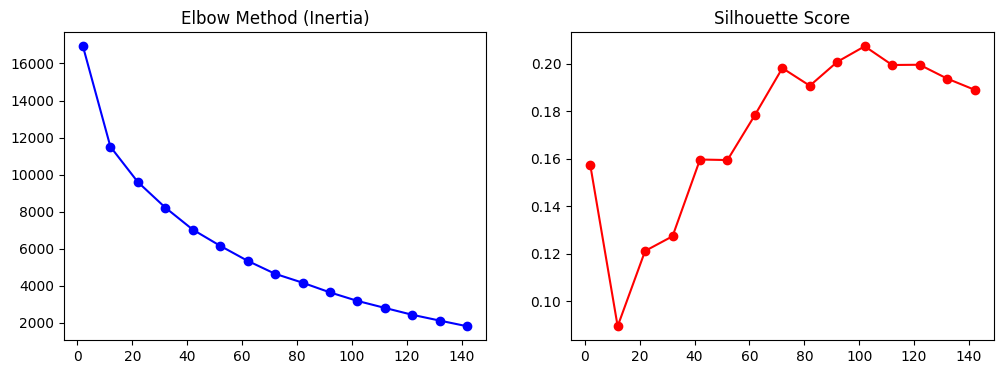

In [6]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_range = range(2, 150, 10) # 2부터 150까지 10 단위로 확인
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_train, kmeans.labels_))

# 그래프 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, "bo-")
plt.title("Elbow Method (Inertia)")

plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, "ro-")
plt.title("Silhouette Score")
plt.show()

In [7]:
from sklearn.cluster import KMeans

# 1. 그래프에서 찾은 최적의 k 설정
best_k = 105 # 그래프 상에서 100을 살짝 넘긴 지점이 피크이므로 105 내외가 적당합니다.

# 2. K-평균 모델 생성 및 훈련
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
y_train_pred = kmeans.fit_predict(X_train)

# 3. 군집 결과 확인 (샘플 수 확인)
import numpy as np
unique, counts = np.unique(y_train_pred, return_counts=True)
print(dict(zip(unique, counts)))

{np.int32(0): np.int64(1), np.int32(1): np.int64(5), np.int32(2): np.int64(2), np.int32(3): np.int64(4), np.int32(4): np.int64(4), np.int32(5): np.int64(4), np.int32(6): np.int64(4), np.int32(7): np.int64(3), np.int32(8): np.int64(3), np.int32(9): np.int64(4), np.int32(10): np.int64(5), np.int32(11): np.int64(3), np.int32(12): np.int64(5), np.int32(13): np.int64(4), np.int32(14): np.int64(7), np.int32(15): np.int64(4), np.int32(16): np.int64(3), np.int32(17): np.int64(3), np.int32(18): np.int64(2), np.int32(19): np.int64(2), np.int32(20): np.int64(2), np.int32(21): np.int64(1), np.int32(22): np.int64(3), np.int32(23): np.int64(1), np.int32(24): np.int64(4), np.int32(25): np.int64(2), np.int32(26): np.int64(4), np.int32(27): np.int64(2), np.int32(28): np.int64(3), np.int32(29): np.int64(3), np.int32(30): np.int64(4), np.int32(31): np.int64(2), np.int32(32): np.int64(2), np.int32(33): np.int64(4), np.int32(34): np.int64(4), np.int32(35): np.int64(4), np.int32(36): np.int64(2), np.int32(3

####  **STEP 5. 아래 `plot_faces` 함수를 이용하여, 클러스터를 시각화하고, 각 클러스터에 비슷한 얼굴이 들어있는지 확인해보세요.**

In [8]:
# plot_faces 함수
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

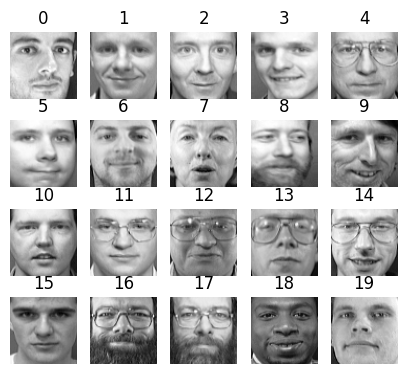

In [9]:
import numpy as np

# 각 클러스터 중심에서 가장 가까운 샘플 찾기
representative_face_indices = np.argmin(kmeans.transform(X_train), axis=0)
representative_faces = X_train[representative_face_indices]

# 시각화 (첫 20개 클러스터 대표 얼굴)
plot_faces(representative_faces[:20], labels=range(20), n_cols=5)

Cluster 10에 속한 샘플 수: 5


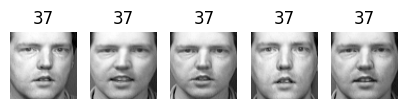

In [10]:
# 확인하고 싶은 클러스터 번호 선택
cluster_id = 10

# 해당 클러스터에 속한 이미지와 실제 타겟(인물 ID) 추출
X_cluster = X_train[y_train_pred == cluster_id]
y_cluster = y_train[y_train_pred == cluster_id]

print(f"Cluster {cluster_id}에 속한 샘플 수: {len(X_cluster)}")

# 시각화 (최대 15개까지)
plot_faces(X_cluster[:15], labels=y_cluster[:15], n_cols=5)